In [1]:
import numpy as np
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
)
from random_matrix.input_statistics.density_function import (
    DensityFunctionTerm,
)
import pickle
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.utils import matrix_utils
from random_matrix.modes import mode_grid_factory
import traceback
from pathlib import Path
import scipy
import matplotlib.pyplot as plt

In [2]:
def spy(
    mat,
    num_blocks: int = 4,
    figsize=(6,6),
    markersize=1,
    line_color="black",
    line_width=0.5,
    title: str = ""
):
    """
    Plot a sparse matrix with block grid lines overlaid (default 4x4 blocks).

    Parameters
    ----------
    mat : scipy.sparse.spmatrix
        Sparse matrix to plot.
    num_blocks : int, optional
        Number of blocks along each axis (default 4).
    figsize : tuple
        Figure size.
    markersize : int
        Size of the markers for spy.
    line_color : str
        Color of the block lines.
    line_width : float
        Width of the block lines.
    """
    plt.figure(figsize=figsize)
    plt.spy(mat, markersize=markersize)
    plt.title(title)
    n = mat.shape[0] // num_blocks  # size of each block

    for i in range(1, num_blocks):
        plt.axhline(i * n - 0.5, color=line_color, lw=line_width)
        plt.axvline(i * n - 0.5, color=line_color, lw=line_width)

    plt.show()

In [3]:
simulation_name = Path(f"memory_effect_test_{0.4}")
parent_data_dir = Path("/mnt/raid/rmt/data/")
cov_path = parent_data_dir / simulation_name / "cov.npz"
cov = scipy.sparse.load_npz(cov_path)

mean_path = parent_data_dir / simulation_name / "mean_S.npy"
mean_S = np.load(mean_path)

integration_results_list_path = (
    parent_data_dir / simulation_name / "integration_result_list.pkl"
)
with open(integration_results_list_path, "rb") as f:
    integration_results_list = pickle.load(f)

In [4]:
n = cov.shape[0] // 4
blocks = []

for i in range(4):
    # extract diagonal block
    block = cov[i * n : (i + 1) * n, i * n : (i + 1) * n]
    blocks.append(block)

# assemble block-diagonal sparse matrix
cov_diag = scipy.sparse.block_diag(blocks, format="csr")
cholesky_diag = matrix_utils.get_cholesky_decomposition(
    matrix_utils.get_real_covariance_matrix(cov_diag)
)
# plt.figure()
# spy(cov_diag)
# plt.figure()
# spy(cholesky_diag)

POWER USED FOR CHOL: 10^-15


In [5]:
block_keys = ["r,r", "r2,r2", "t,t"]
cholesky_blocks = {}
for block_key in block_keys:
    new_cov_block = matrix_utils.get_cov_block(cov, block_key)
    new_real_cov_block = matrix_utils.get_real_covariance_matrix(new_cov_block)
    new_cholesky_block = matrix_utils.get_cholesky_decomposition(
        new_real_cov_block
    )
    cholesky_blocks[block_key] = new_cholesky_block

chol = matrix_utils.get_cholesky_decomposition(
    matrix_utils.get_real_covariance_matrix(cov)
)
chol_dict = cholesky_blocks

POWER USED FOR CHOL: 10^-15
POWER USED FOR CHOL: 10^-15
POWER USED FOR CHOL: 10^-15
POWER USED FOR CHOL: 10^-15


<Figure size 640x480 with 0 Axes>

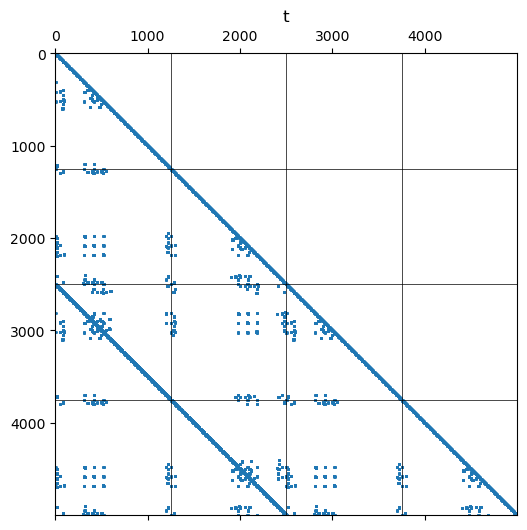

<Figure size 640x480 with 0 Axes>

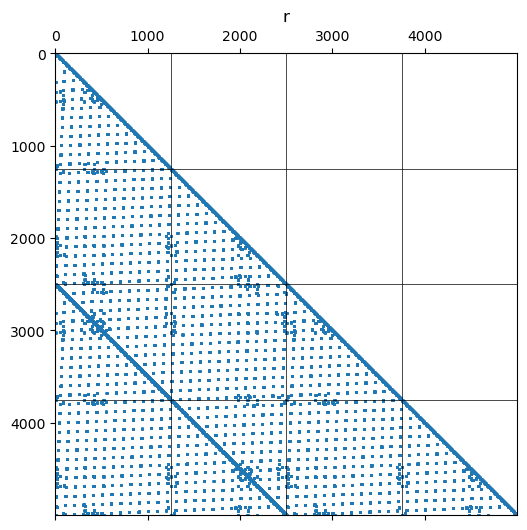

<Figure size 640x480 with 0 Axes>

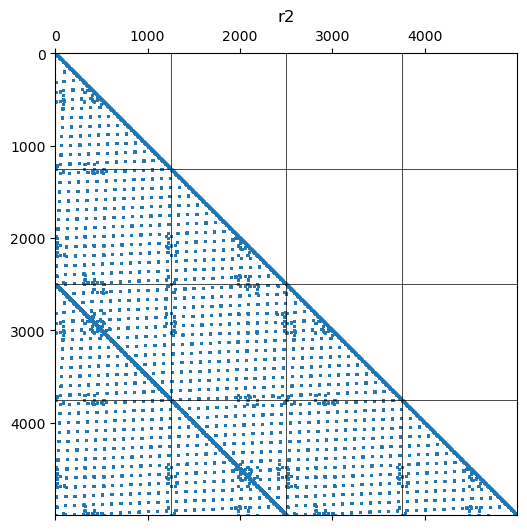

<Figure size 640x480 with 0 Axes>

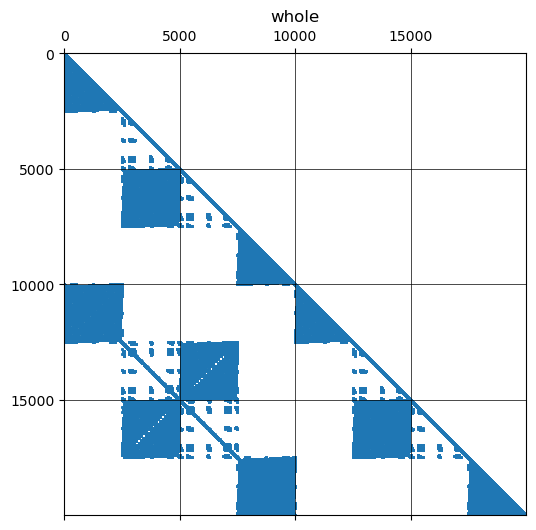

In [6]:
plt.figure()
spy(cholesky_blocks["t,t"],title="t")
plt.figure()
spy(cholesky_blocks["r,r"],title="r")
plt.figure()
spy(cholesky_blocks["r2,r2"],title="r2")
plt.figure()
spy(chol,title="whole")

In [7]:
def reorder_block(
    elements: np.ndarray,
) -> np.ndarray:

    length_of_elements, num_matrices = np.shape(elements)
    size_of_block = int(np.sqrt(len(elements)))

    even_row_indices = np.sort(
        np.concatenate(
            (
                np.arange(0, length_of_elements, 4),
                np.arange(1, length_of_elements, 4),
            )
        )
    )
    odd_row_indices = np.sort(
        np.concatenate(
            (
                np.arange(2, length_of_elements, 4),
                np.arange(3, length_of_elements, 4),
            )
        )
    )

    even_rows = elements[even_row_indices].reshape(
        int(size_of_block / 2), size_of_block, num_matrices
    )
    odd_rows = elements[odd_row_indices].reshape(
        int(size_of_block / 2), size_of_block, num_matrices
    )
    final = np.empty(
        (
            even_rows.shape[0] + odd_rows.shape[0],
            even_rows.shape[1],
            num_matrices,
        ),
        dtype=np.complex128,
    )
    final[::2, :, :] = even_rows
    final[1::2, :, :] = odd_rows
    return final


def S_sampler(
    mean_S,
    chol,
    num_matrices: int = 1,
    seed: int = 1,
) -> np.ndarray:

    size_of_S, _ = np.shape(mean_S)
    size_of_block = int(size_of_S / 2)
    num_random_numbers, _ = np.shape(chol)

    # Generate random numbers for the matrices
    np.random.seed(seed)
    random_numbers = np.random.randn(num_random_numbers, num_matrices)
    modified_random_numbers = chol @ random_numbers

    # Pick out the correct values
    reals = modified_random_numbers[: int(num_random_numbers / 2)]
    imags = modified_random_numbers[int(num_random_numbers / 2) :]

    # Extract matrix elements from random numbers
    num_random_numbers = int(num_random_numbers / 2)
    r = (
        reals[: int(num_random_numbers / 4)]
        + 1j * imags[: int(num_random_numbers / 4)]
    )
    t = (
        reals[int(num_random_numbers / 4) : int(num_random_numbers / 2)]
        + 1j * imags[int(num_random_numbers / 4) : int(num_random_numbers / 2)]
    )
    t2 = (
        reals[int(num_random_numbers / 2) : int(num_random_numbers * 3 / 4)]
        + 1j
        * imags[int(num_random_numbers / 2) : int(num_random_numbers * 3 / 4)]
    )
    r2 = (
        reals[int(num_random_numbers * 3 / 4) :]
        + 1j * imags[int(num_random_numbers * 3 / 4) :]
    )

    # ----------------------------------------------
    # debugging
    # ------------------------------------------

    # Reorder the randomly generated numbers into the correct shapes
    r_mat = reorder_block(r)
    t_mat = reorder_block(t)
    t2_mat = reorder_block(t2)
    r2_mat = reorder_block(r2)

    # Add identity to transmission matrices
    t_mat = t_mat  # + identity[:, :, np.newaxis]
    t2_mat = t2_mat  # + identity[:, :, np.newaxis]

    top = np.hstack([r_mat, t2_mat])
    bottom = np.hstack([t_mat, r2_mat])
    whole = np.vstack([top, bottom])

    # Add the mean matrix to each instance
    whole = whole  # - mean_S[:, :, np.newaxis]
    output = np.transpose(whole, (2, 0, 1))
    return output


def S_sampler_cholesky_dict(
    mean_S,
    chol_dict,
    num_matrices: int = 1,
    seed: int | bool = None,
) -> np.ndarray:
    if seed is not None:
        np.random.seed(seed)

    size_of_S, _ = np.shape(mean_S)
    size_of_t = int(size_of_S // 2)
    num_random_numbers, _ = np.shape(chol_dict["t,t"])

    # Generate random numbers for the matrices
    np.random.seed(1)
    random_numbers = np.random.randn(3, num_random_numbers, num_matrices)
    modified_random_numbers_t = chol_dict["t,t"] @ random_numbers[0]
    modified_random_numbers_r = chol_dict["r,r"] @ random_numbers[1]
    modified_random_numbers_r2 = chol_dict["r2,r2"] @ random_numbers[2]

    # Pick out the correct values
    reals_t = modified_random_numbers_t[: int(num_random_numbers / 2)]
    imags_t = modified_random_numbers_t[int(num_random_numbers / 2) :]
    reals_r = modified_random_numbers_r[: int(num_random_numbers / 2)]
    imags_r = modified_random_numbers_r[int(num_random_numbers / 2) :]
    reals_r2 = modified_random_numbers_r2[: int(num_random_numbers / 2)]
    imags_r2 = modified_random_numbers_r2[int(num_random_numbers / 2) :]

    r = reals_r + 1j * imags_r
    t = reals_t + 1j * imags_t
    r2 = reals_r2 + 1j * imags_r2

    # Reorder the randomly generated numbers into the correct shapes
    r_mat = reorder_block(r).transpose(2, 0, 1)
    t_mat = reorder_block(t).transpose(2, 0, 1)
    r2_mat = reorder_block(r2).transpose(2, 0, 1)

    sigma_p = matrix_utils.get_S_block_reciprocity_matrix(size_of_t)
    t2_mat = (
        sigma_p[None, :, :] @ matrix_utils.r_sym(t_mat) @ sigma_p[None, :, :]
    )
    S_matrices = np.block(
        [[r_mat, t2_mat], [t_mat, r2_mat]]
    )
    return S_matrices

In [8]:
S_w = S_sampler(mean_S, chol, 100)
S_s = S_sampler_cholesky_dict(mean_S, chol_dict, 100)

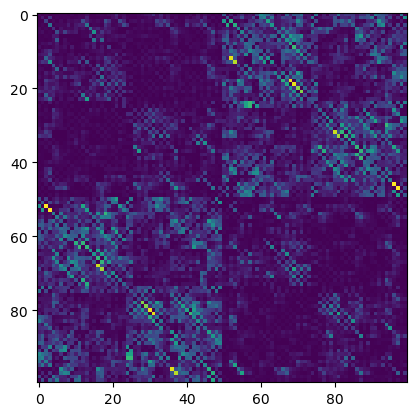

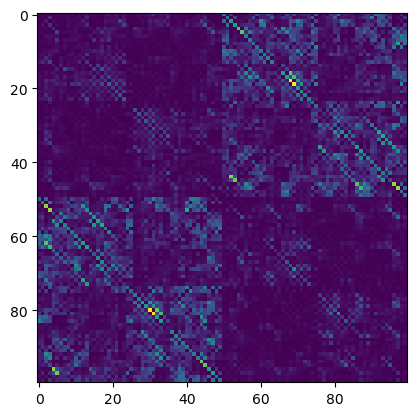

In [11]:
plt.figure()
plt.imshow(np.abs(S_w[0]))
plt.figure()
plt.imshow(np.abs(S_s[0]))

In [9]:




# ----------------------------------------------
# debugging
# ------------------------------------------




# Add identity to transmission matrices

top = np.hstack([r_mat, t2_mat])
bottom = np.hstack([t_mat, r2_mat])
whole = np.vstack([top, bottom])

# Add the mean matrix to each instance
whole = whole  # - mean_S[:, :, np.newaxis]
output = np.transpose(whole, (2, 0, 1))
return output

NameError: name 'r_mat' is not defined

In [ ]:
S_w = S_sampler(mean_S, chol)[0]
r_w = matrix_utils.get_block(S_w, "r")
t_w = matrix_utils.get_block(S_w, "t")
r2_w = matrix_utils.get_block(S_w, "r2")
t2_w = matrix_utils.get_block(S_w, "t2")

sigma_p = matrix_utils.get_S_block_reciprocity_matrix(len(r_w))

print(np.max(np.abs(r_w - sigma_p @ matrix_utils.r_sym(r_w) @ sigma_p)))
print(np.max(np.abs(r2_w - sigma_p @ matrix_utils.r_sym(r2_w) @ sigma_p)))
print(np.max(np.abs(t_w - sigma_p @ matrix_utils.r_sym(t2_w) @ sigma_p)))
print(np.max(np.abs(t2_w - sigma_p @ matrix_utils.r_sym(t_w) @ sigma_p)))

1.9607393469507893e-07
1.7332025380189457e-07
1.7577159119020103e-07
1.7577159119020103e-07


In [ ]:
S_w = S_sampler_dict(mean_S, cholesky_blocks)
# r_w = matrix_utils.get_block(S_w, "r")
# t_w = matrix_utils.get_block(S_w, "t")
# r2_w = matrix_utils.get_block(S_w, "r2")
# t2_w = matrix_utils.get_block(S_w, "t2")

# sigma_p = matrix_utils.get_S_block_reciprocity_matrix(len(r_w))

# print(np.max(np.abs(r_w - sigma_p @ matrix_utils.r_sym(r_w) @ sigma_p)))
# print(np.max(np.abs(r2_w - sigma_p @ matrix_utils.r_sym(r2_w) @ sigma_p)))
# print(np.max(np.abs(t_w - sigma_p @ matrix_utils.r_sym(t2_w) @ sigma_p)))
# print(np.max(np.abs(t2_w - sigma_p @ matrix_utils.r_sym(t_w) @ sigma_p)))

ValueError: too many values to unpack (expected 2)

In [ ]:
cholesky_blocks["t,t"]

<5000x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 26285 stored elements in Compressed Sparse Column format>

In [ ]:
t = matrix_utils.get_block(S_whole[0], "t")
t2 = matrix_utils.get_block(S_whole[0], "t2")

print(np.max(t - matrix_utils.r_sym(t2)))

NameError: name 'S_whole' is not defined

In [ ]:
plt.imshow(np.abs(matrix_utils.get_block(S_separate[0], "t2")))

In [ ]:
t_separate = matrix_utils.get_block(S_separate, "t")
t_whole = matrix_utils.get_block(S_whole, "t")
sig = matrix_utils.get_S_reciprocity_matrix(len(S_whole[0]))

In [ ]:
print(np.max(S_whole[0] - sig @ S_whole[0].T @ sig))

In [ ]:
print(t_whole)

In [ ]:
size_of_S, _ = np.shape(mean_S)
size_of_block = int(size_of_S / 2)
num_random_numbers, _ = np.shape(cholesky_whole)
num_matrices = 1
# Generate random numbers for the matrices
np.random.seed(1)
random_numbers = np.random.randn(num_random_numbers, num_matrices)
modified_random_numbers_s = cholesky_separate @ random_numbers
modified_random_numbers_w = cholesky_whole @ random_numbers

num_elements = len(random_numbers)
segment_len = num_elements // 8  # each A_real, A_imag, etc.
A_real_s = modified_random_numbers_s[0 * segment_len : 1 * segment_len]
A_imag_s = modified_random_numbers_s[1 * segment_len : 2 * segment_len]
B_real_s = modified_random_numbers_s[2 * segment_len : 3 * segment_len]
B_imag_s = modified_random_numbers_s[3 * segment_len : 4 * segment_len]
C_real_s = modified_random_numbers_s[4 * segment_len : 5 * segment_len]
C_imag_s = modified_random_numbers_s[5 * segment_len : 6 * segment_len]
D_real_s = modified_random_numbers_s[6 * segment_len : 7 * segment_len]
D_imag_s = modified_random_numbers_s[7 * segment_len : 8 * segment_len]

A_real_w = modified_random_numbers_w[0 * segment_len : 1 * segment_len]
B_real_w = modified_random_numbers_w[1 * segment_len : 2 * segment_len]
C_real_w = modified_random_numbers_w[2 * segment_len : 3 * segment_len]
D_real_w = modified_random_numbers_w[3 * segment_len : 4 * segment_len]
A_imag_w = modified_random_numbers_w[4 * segment_len : 5 * segment_len]
B_imag_w = modified_random_numbers_w[5 * segment_len : 6 * segment_len]
C_imag_w = modified_random_numbers_w[6 * segment_len : 7 * segment_len]
D_imag_w = modified_random_numbers_w[7 * segment_len : 8 * segment_len]

In [ ]:
print(np.max(A_real_w - A_real_s))
print(np.max(A_imag_w - A_imag_s))

In [ ]:
modified_random_numbers_w